In [100]:
import csv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
all_data = pd.read_csv("/Users/christinauko/Desktop/Python/Project/Life-Expectancy-and-GDP-Starter/all_data.csv")
print(all_data)

     Country  Year  Life expectancy at birth (years)           GDP
0      Chile  2000                              77.3  7.786093e+10
1      Chile  2001                              77.3  7.097992e+10
2      Chile  2002                              77.8  6.973681e+10
3      Chile  2003                              77.9  7.564346e+10
4      Chile  2004                              78.0  9.921039e+10
..       ...   ...                               ...           ...
91  Zimbabwe  2011                              54.9  1.209845e+10
92  Zimbabwe  2012                              56.6  1.424249e+10
93  Zimbabwe  2013                              58.0  1.545177e+10
94  Zimbabwe  2014                              59.2  1.589105e+10
95  Zimbabwe  2015                              60.7  1.630467e+10

[96 rows x 4 columns]


In [26]:
all_data.dtypes

Country                              object
Year                                  int64
Life expectancy at birth (years)    float64
GDP                                 float64
dtype: object

In [28]:
all_data['Country'].describe()

count        96
unique        6
top       Chile
freq         16
Name: Country, dtype: object

In [30]:
all_data['Year'].describe()

count      96.000000
mean     2007.500000
std         4.633971
min      2000.000000
25%      2003.750000
50%      2007.500000
75%      2011.250000
max      2015.000000
Name: Year, dtype: float64

In [32]:
all_data['GDP'].describe()

count    9.600000e+01
mean     3.880499e+12
std      5.197561e+12
min      4.415703e+09
25%      1.733018e+11
50%      1.280220e+12
75%      4.067510e+12
max      1.810000e+13
Name: GDP, dtype: float64

In [67]:
all_data.head(5)

,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


In [65]:
max_LE = all_data['Life expectancy at birth (years)'].max()
min_LE = all_data['Life expectancy at birth (years)'].min()
print(max_LE, min_LE)

81.0 44.3


In [69]:
max_GDP = all_data['GDP'].max()
min_GDP = all_data['GDP'].min()
print(max_GDP, min_GDP)

18100000000000.0 4415702800.0


In [81]:
top_GDP_per_country = all_data.groupby('Country')['GDP'].max()
lowest_GDP_per_country = all_data.groupby('Country')['GDP'].min()
mean_GDP_per_country = all_data.groupby('Country')['GDP'].mean()
print(top_GDP_per_country)
print(lowest_GDP_per_country)
print(mean_GDP_per_country)

Country
Chile                       2.783840e+11
China                       1.106470e+13
Germany                     3.890610e+12
Mexico                      1.298460e+12
United States of America    1.810000e+13
Zimbabwe                    1.630467e+10
Name: GDP, dtype: float64
Country
Chile                       6.973681e+10
China                       1.211350e+12
Germany                     1.949950e+12
Mexico                      6.836480e+11
United States of America    1.030000e+13
Zimbabwe                    4.415703e+09
Name: GDP, dtype: float64
Country
Chile                       1.697888e+11
China                       4.957714e+12
Germany                     3.094776e+12
Mexico                      9.766506e+11
United States of America    1.407500e+13
Zimbabwe                    9.062580e+09
Name: GDP, dtype: float64


In [93]:
max_by_year = all_data.groupby(['Country','Year']).agg({'Life expectancy at birth (years)':'max'})
max_by_year.columns = ['max_GDP']
max_by_year = max_by_year.reset_index()
print(max_by_year)

     Country  Year  max_GDP
0      Chile  2000     77.3
1      Chile  2001     77.3
2      Chile  2002     77.8
3      Chile  2003     77.9
4      Chile  2004     78.0
..       ...   ...      ...
91  Zimbabwe  2011     54.9
92  Zimbabwe  2012     56.6
93  Zimbabwe  2013     58.0
94  Zimbabwe  2014     59.2
95  Zimbabwe  2015     60.7

[96 rows x 3 columns]


In [95]:
all_data_pivot = pd.pivot_table(all_data,
               index = 'Year',
               columns = 'Country',
               values = 'GDP',
               aggfunc = 'max')
print(all_data_pivot)

Country         Chile         China       Germany        Mexico  \
Year                                                              
2000     7.786093e+10  1.211350e+12  1.949950e+12  6.836480e+11   
2001     7.097992e+10  1.339400e+12  1.950650e+12  7.247040e+11   
2002     6.973681e+10  1.470550e+12  2.079140e+12  7.415600e+11   
2003     7.564346e+10  1.660290e+12  2.505730e+12  7.132840e+11   
2004     9.921039e+10  1.955350e+12  2.819250e+12  7.702680e+11   
2005     1.229650e+11  2.285970e+12  2.861410e+12  8.663460e+11   
2006     1.547880e+11  2.752130e+12  3.002450e+12  9.652810e+11   
2007     1.736060e+11  3.552180e+12  3.439950e+12  1.043470e+12   
2008     1.796380e+11  4.598210e+12  3.752370e+12  1.101280e+12   
2009     1.723890e+11  5.109950e+12  3.418010e+12  8.949490e+11   
2010     2.185380e+11  6.100620e+12  3.417090e+12  1.051130e+12   
2011     2.522520e+11  7.572550e+12  3.757700e+12  1.171190e+12   
2012     2.671220e+11  8.560550e+12  3.543980e+12  1.186600e+1

<function matplotlib.pyplot.show(close=None, block=None)>

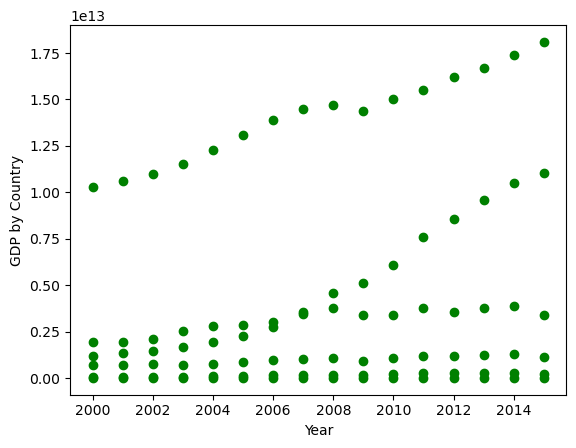

In [134]:
plt.scatter(x = all_data.Year,y = all_data.GDP, color = 'green')
country = ['Chile', 'China', 'Germany', 'Mexico', 'United States of America', 'Zimbabwe']
plt.plot()
plt.xlabel('Year')
plt.ylabel('GDP by Country')
plt.show

In [132]:
all_dataMeans = all_data.drop("Year", axis = 1).groupby("Country").mean().reset_index()
print(all_dataMeans)

                    Country  Life expectancy at birth (years)           GDP
0                     Chile                          78.94375  1.697888e+11
1                     China                          74.26250  4.957714e+12
2                   Germany                          79.65625  3.094776e+12
3                    Mexico                          75.71875  9.766506e+11
4  United States of America                          78.06250  1.407500e+13
5                  Zimbabwe                          50.09375  9.062580e+09


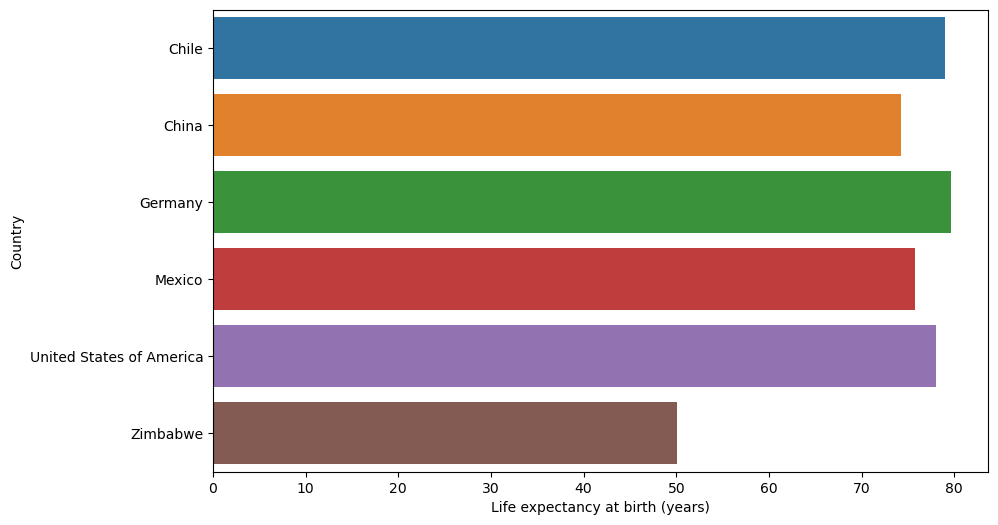

In [146]:
plt.figure(figsize=(10,6))
sns.barplot(x="Life expectancy at birth (years)", y="Country", data=all_dataMeans)
plt.xlabel("Life expectancy at birth (years)");

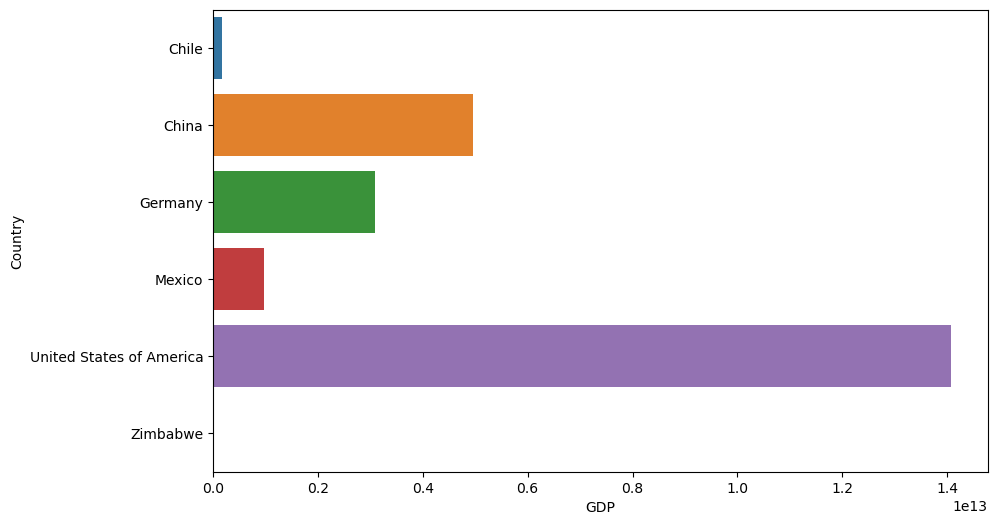

In [149]:
plt.figure(figsize=(10,6))
sns.barplot(x="GDP", y="Country", data=all_dataMeans)
plt.xlabel("GDP");

In [ ]:
#Looks like the US has a greater GDP and Life expectancy than the other countries.
#To view the trend of both metrics over the years, we'll use a line graph.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


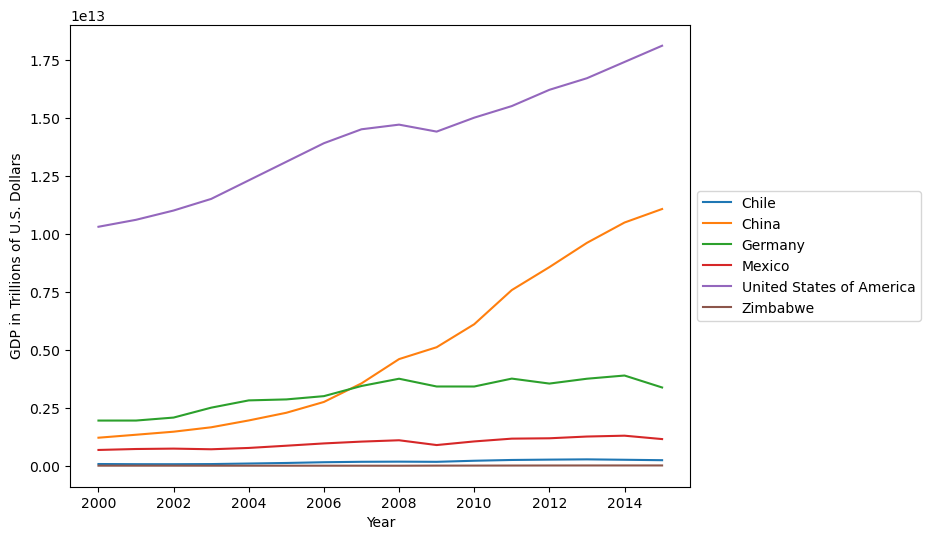

In [157]:
plt.figure(figsize=(8,6))
sns.lineplot(x=all_data.Year, y=all_data.GDP, hue=all_data.Country)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
plt.ylabel("GDP in Trillions of U.S. Dollars");

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

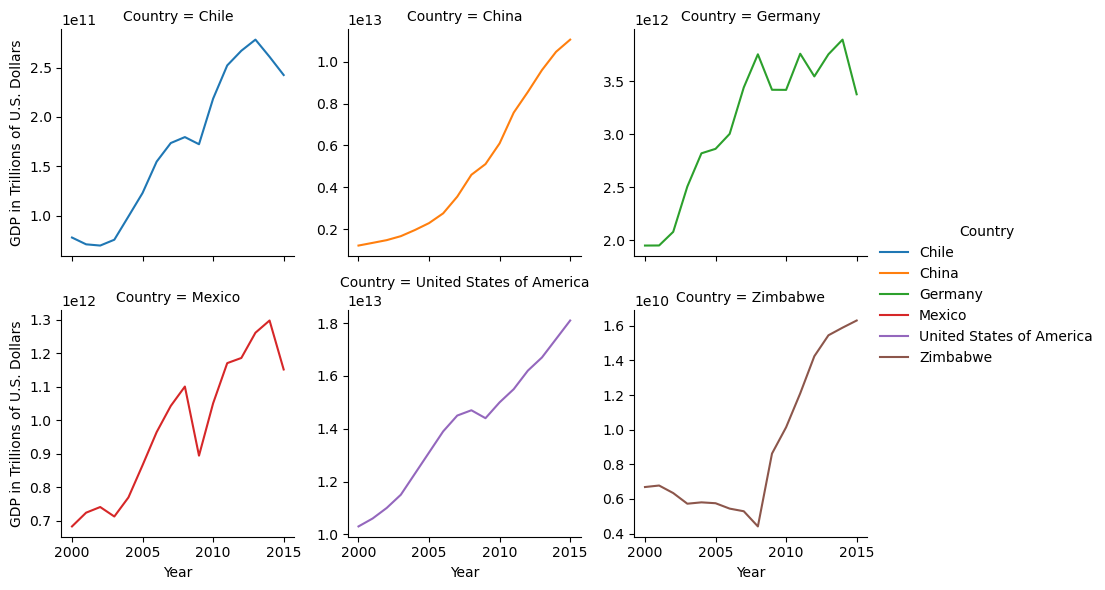

In [176]:
graphGDP = sns.FacetGrid(all_data, col="Country", col_wrap=3,
                      hue = "Country", sharey = False)

graphGDP = (graphGDP.map(sns.lineplot,"Year","GDP")
         .add_legend()
         .set_axis_labels("Year","GDP in Trillions of U.S. Dollars"))

graphGDP;

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


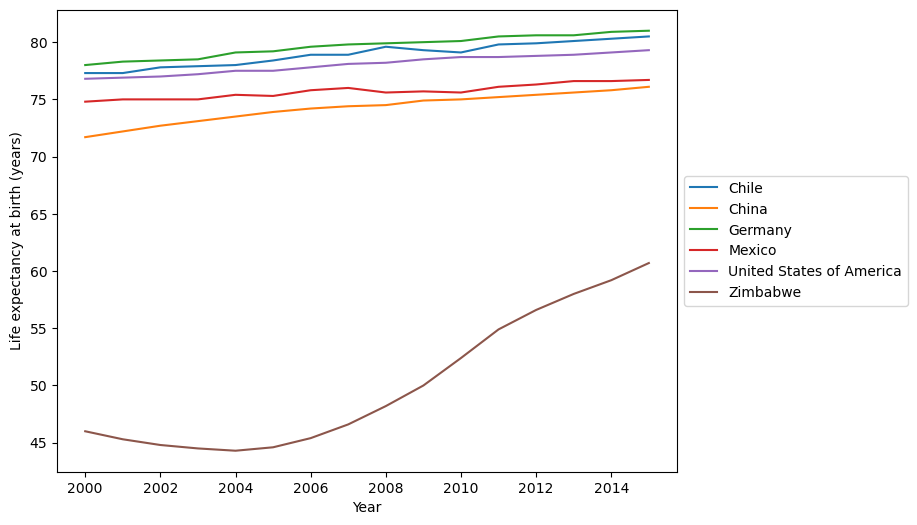

In [171]:
all_data = all_data.rename({"Life expectancy at birth (years)":"LEABY"}, axis = "columns")
plt.figure(figsize=(8,6))
sns.lineplot(x=all_data.Year, y=all_data.LEABY, hue=all_data.Country)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
plt.ylabel("Life expectancy at birth (years)");


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

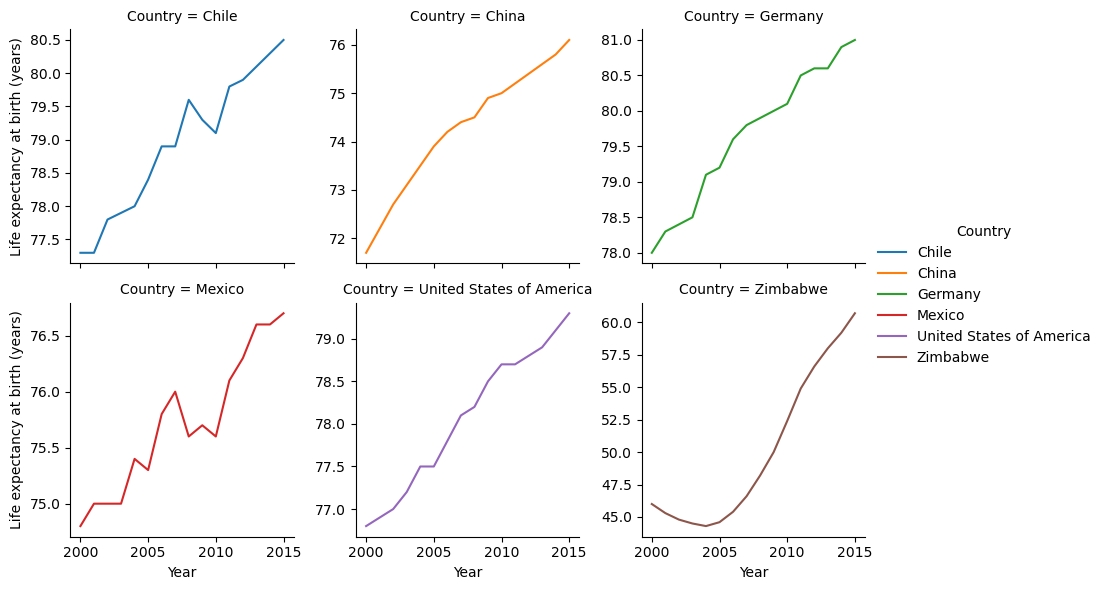

In [179]:
graphLEABY = sns.FacetGrid(all_data, col="Country", col_wrap=3,
                      hue = "Country", sharey = False)

graphLEABY = (graphLEABY.map(sns.lineplot,"Year","LEABY")
         .add_legend()
         .set_axis_labels("Year","Life expectancy at birth (years)"))

graphLEABY;

In [ ]:
# This project This project was able to make quite a few data visualizations with the data even though there were only 96 rows and 4 columns.

#The project was also able to answer some of the questions:

#Has life expectancy increased over time in the six nations?
#Yes with Zimbabwe having the greatest increase.
#Has GDP increased over time in the six nations?
#GDP has also increased for all countries in our list, especially for China.
#Is there a correlation between GDP and life expectancy of a country?
#Yes there is a positive correlation between GDP and life expectancy for countries in our list.
#What is the average life expectancy in these nations?
#Average life expectancy was between mid to high 70s for the countries except for Zimbabwe which was 50.

